In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
data = pd.read_csv("data.csv")

X_train = data[['feature1', 'feature2']].values
y_train = data['label'].values

m, n = X_train.shape

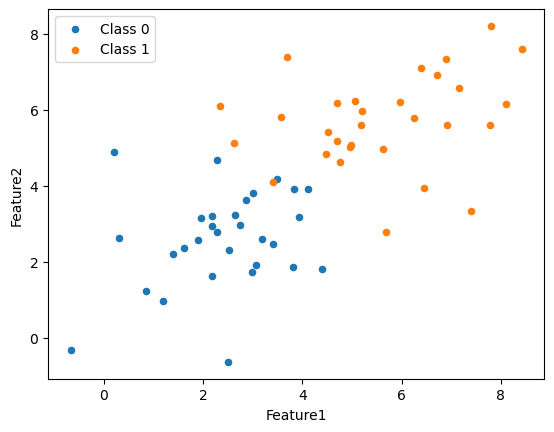

In [44]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend()
plt.show()

##### Implementation Plan
1. Sigmoid Function.
2. Cost Function.
3. Gradient Function.
4. Gradient Descent Function
5. Predict Function

In [51]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [52]:
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, 1e-10, 1 - 1e-10)
        cost += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    return cost / m

In [53]:
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        error = g - y[i]
        grad_b += error
        for j in range(n):
            grad_w[j] += error * X[i, j]
    grad_b /= m
    grad_w /= m
    return grad_b, grad_w

In [54]:
def gradient_descent(X, y, alpha, iterations):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    cost_history = []
    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)
        w -= alpha * grad_w
        b -= alpha * grad_b
        if i % 100 == 0:
            cost = cost_function(X, y, w, b)
            cost_history.append(cost)
            print(f"Iteration {i:5d} | Cost = {cost:.6f}")
    return w, b, cost_history

In [55]:
def predict(X, w, b):
    m = X.shape[0]
    predictions = np.zeros(m)
    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        predictions[i] = 1 if g >= 0.5 else 0
    return predictions

In [61]:
learning_rate = 0.01
iterations = 10000
final_w, final_b, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate,
    iterations
)
predictions = predict(X_train, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print("\nFinal Parameters")
print("w =", final_w)
print("b =", final_b)
print(f"Training Accuracy = {accuracy:.2f}%")

Iteration     0 | Cost = 0.681443
Iteration   100 | Cost = 0.607466
Iteration   200 | Cost = 0.584773
Iteration   300 | Cost = 0.563923
Iteration   400 | Cost = 0.544696
Iteration   500 | Cost = 0.526913
Iteration   600 | Cost = 0.510428
Iteration   700 | Cost = 0.495115
Iteration   800 | Cost = 0.480864
Iteration   900 | Cost = 0.467576
Iteration  1000 | Cost = 0.455165
Iteration  1100 | Cost = 0.443553
Iteration  1200 | Cost = 0.432669
Iteration  1300 | Cost = 0.422451
Iteration  1400 | Cost = 0.412843
Iteration  1500 | Cost = 0.403792
Iteration  1600 | Cost = 0.395255
Iteration  1700 | Cost = 0.387189
Iteration  1800 | Cost = 0.379557
Iteration  1900 | Cost = 0.372326
Iteration  2000 | Cost = 0.365466
Iteration  2100 | Cost = 0.358948
Iteration  2200 | Cost = 0.352747
Iteration  2300 | Cost = 0.346842
Iteration  2400 | Cost = 0.341211
Iteration  2500 | Cost = 0.335835
Iteration  2600 | Cost = 0.330698
Iteration  2700 | Cost = 0.325783
Iteration  2800 | Cost = 0.321077
Iteration  290

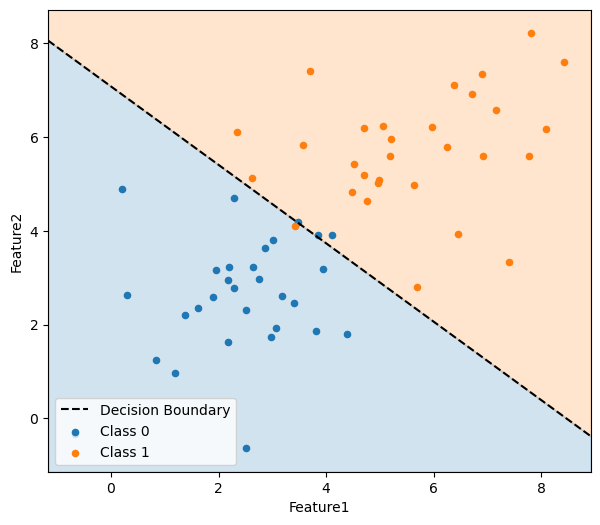

In [62]:
if abs(final_w[1]) > 1e-10:
    slope = -final_w[0] / final_w[1]
    intercept = -final_b / final_w[1]

    xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

    xd = np.array([xmin, xmax])
    yd = slope * xd + intercept

    plt.figure(figsize=(7, 6))

    plt.plot(xd, yd, 'k--', label='Decision Boundary')

    plt.fill_between(xd, yd, ymin,
                     color='tab:blue', alpha=0.2)
    plt.fill_between(xd, yd, ymax,
                     color='tab:orange', alpha=0.2)
    plt.scatter(X_train[y_train == 0, 0],
                X_train[y_train == 0, 1],
                color='tab:blue',
                label='Class 0',
                s=20)
    plt.scatter(X_train[y_train == 1, 0],
                X_train[y_train == 1, 1],
                color='tab:orange',
                label='Class 1',
                s=20)
    plt.xlabel("Feature1")
    plt.ylabel("Feature2")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.show()
else:
    print("Cannot plot decision boundary because w[1] is zero.")